Array: [2, 5, 10, 15, 23, 35, 48, 60, 75, 90, 105, 120]
Searching for: 35
Found at index: 5
Comparisons: 3

      Size    IS Time(ms)    BS Time(ms)     IS Comparisons     BS Comparisons
--------------------------------------------------------------------------------
      1000         0.0023         0.0016                  5                 10
      5000         0.0013         0.0032                  3                 12
     10000         0.0017         0.0024                  4                 12
     50000         0.0010         0.0025                  2                 16
    100000         0.0027         0.0035                  5                 16


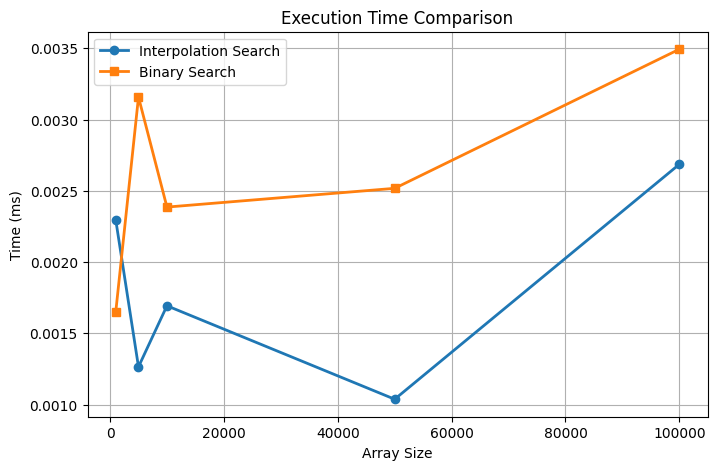

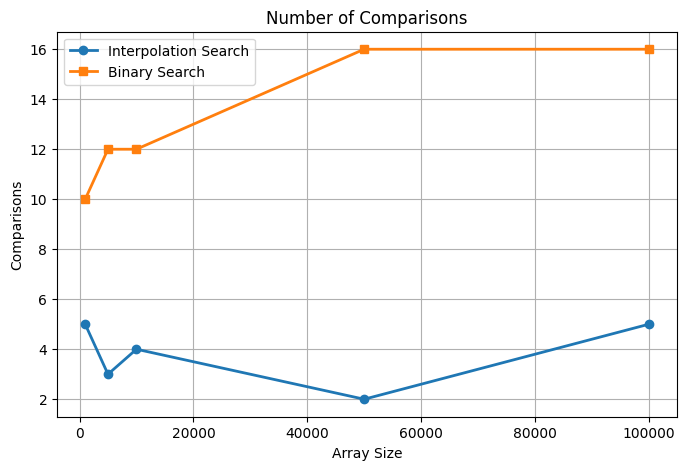

In [1]:
import time
import random
import matplotlib.pyplot as plt


# ---------------- Interpolation Search ----------------
def interpolation_search(arr, target):
    low, high = 0, len(arr) - 1
    comparisons = 0

    while low <= high and arr[low] <= target <= arr[high]:
        comparisons += 1

        if low == high:
            if arr[low] == target:
                return low, comparisons
            return -1, comparisons

        # Avoid division by zero
        if arr[high] == arr[low]:
            break

        # Interpolation formula
        pos = low + int(((target - arr[low]) * (high - low)) /
                        (arr[high] - arr[low]))

        if arr[pos] == target:
            return pos, comparisons
        elif arr[pos] < target:
            low = pos + 1
        else:
            high = pos - 1

    return -1, comparisons


# ---------------- Binary Search ----------------
def binary_search(arr, target):
    low, high = 0, len(arr) - 1
    comparisons = 0

    while low <= high:
        comparisons += 1
        mid = (low + high) // 2

        if arr[mid] == target:
            return mid, comparisons
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1

    return -1, comparisons


# ---------------- Performance Analysis ----------------
def performance_analysis():
    sizes = [1000, 5000, 10000, 50000, 100000]

    is_times = []
    bs_times = []
    is_comps = []
    bs_comps = []

    print(f"{'Size':>10} {'IS Time(ms)':>14} {'BS Time(ms)':>14} "
          f"{'IS Comparisons':>18} {'BS Comparisons':>18}")
    print("-" * 80)

    for size in sizes:

        arr = sorted(random.sample(range(size * 10), size))
        target = arr[random.randint(0, size - 1)]

        # Interpolation Search
        start = time.perf_counter()
        for _ in range(100):
            idx_is, comp_is = interpolation_search(arr, target)
        is_time = (time.perf_counter() - start) / 100 * 1000

        # Binary Search
        start = time.perf_counter()
        for _ in range(100):
            idx_bs, comp_bs = binary_search(arr, target)
        bs_time = (time.perf_counter() - start) / 100 * 1000

        is_times.append(is_time)
        bs_times.append(bs_time)
        is_comps.append(comp_is)
        bs_comps.append(comp_bs)

        print(f"{size:>10} {is_time:>14.4f} {bs_time:>14.4f} "
              f"{comp_is:>18} {comp_bs:>18}")

    # ---------------- Graph 1 ----------------
    plt.figure(figsize=(8, 5))
    plt.plot(sizes, is_times, marker='o', linewidth=2,
             label='Interpolation Search')
    plt.plot(sizes, bs_times, marker='s', linewidth=2,
             label='Binary Search')

    plt.title("Execution Time Comparison")
    plt.xlabel("Array Size")
    plt.ylabel("Time (ms)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------------- Graph 2 ----------------
    plt.figure(figsize=(8, 5))
    plt.plot(sizes, is_comps, marker='o', linewidth=2,
             label='Interpolation Search')
    plt.plot(sizes, bs_comps, marker='s', linewidth=2,
             label='Binary Search')

    plt.title("Number of Comparisons")
    plt.xlabel("Array Size")
    plt.ylabel("Comparisons")
    plt.legend()
    plt.grid(True)
    plt.show()


# ---------------- Main Program ----------------
arr = [2, 5, 10, 15, 23, 35, 48, 60, 75, 90, 105, 120]
target = 35

idx, comps = interpolation_search(arr, target)

print("Array:", arr)
print("Searching for:", target)
print("Found at index:", idx)
print("Comparisons:", comps)
print()

performance_analysis()

